# 📊 Marketing Funnel & Conversion Performance Analysis
### Future Intern — Data Science & Analytics Internship | Task 3

---

**Intern:** Divya Mohan  
**Internship:** Future Intern — Data Science & Analytics  
**Task:** Task 3 — Marketing Funnel & Conversion Performance Analysis  
**Dataset:** Marketing_Funnel_Dataset.csv (Custom Dataset — 1000 Records)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly  

---

## 🎯 Objective
Perform an end-to-end analysis of the marketing funnel to:
- Understand customer movement through funnel stages
- Identify the best performing channels and campaigns
- Analyse conversion rates, ROI, and ad spend efficiency
- Extract actionable business insights for marketing decisions


## 📋 Table of Contents

1. [Import Libraries](#1)
2. [Load & Explore Dataset](#2)
3. [Data Cleaning & Feature Engineering](#3)
4. [Funnel Stage Analysis](#4)
5. [Conversion Rate Analysis](#5)
6. [ROI & Ad Spend Analysis](#6)
7. [Channel Performance Analysis](#7)
8. [Campaign Performance Analysis](#8)
9. [Customer Segment Analysis](#9)
10. [Device & Region Analysis](#10)
11. [Time Series / Monthly Trend Analysis](#11)
12. [Correlation Heatmap](#12)
13. [Key Insights & Summary](#13)
14. [Export Results](#14)


---
## 1. Import Libraries <a id='1'></a>


In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Plot Settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ All libraries imported successfully!')


✅ All libraries imported successfully!


---
## 2. Load & Explore Dataset <a id='2'></a>


In [5]:
# Load Dataset
# Load Dataset
df = pd.read_csv(r"C:\Marketing_Funnel_Dataset.csv")

print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\n--- First 5 Rows ---')
df.head()

print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\n--- First 5 Rows ---')
df.head()


Dataset Shape: 1000 rows × 20 columns

--- First 5 Rows ---
Dataset Shape: 1000 rows × 20 columns

--- First 5 Rows ---


,Customer_ID,Campaign_Name,Campaign_Channel,Funnel_Stage,Date,Impressions,Clicks,Website_Visits,Leads_Generated,Sign_Ups,Add_To_Cart,Purchases,Revenue,Ad_Spend,Cost_Per_Click,Conversion_Rate,ROI,Customer_Segment,Device,Region
0,CUST1000,PPC Ads,YouTube,Conversion,23-11-2024,16295,1544,1339,220,48,23,10,2060.23,3911.60,2.53,0.65,-47.33,Premium,Tablet,West
1,CUST1001,Referral Program,YouTube,Intent,27-02-2024,1360,58,40,12,2,1,0,0.00,2551.76,44.00,0.00,-100.00,New,Mobile,West
2,CUST1002,SEO,Instagram,Consideration,13-01-2024,38658,937,840,237,99,62,23,10397.83,1851.82,1.98,2.45,461.49,Premium,Tablet,East
3,CUST1003,PPC Ads,Email,Consideration,20-05-2024,45232,1420,1193,224,84,49,21,8201.66,1459.39,1.03,1.48,461.99,Premium,Mobile,South
4,CUST1004,Social Media,YouTube,Conversion,05-05-2024,11784,523,305,42,22,7,2,398.80,3249.73,6.21,0.38,-87.73,Premium,Desktop,North


In [6]:
# Dataset Info
print('--- Dataset Info ---')
df.info()


--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       1000 non-null   str    
 1   Campaign_Name     1000 non-null   str    
 2   Campaign_Channel  1000 non-null   str    
 3   Funnel_Stage      1000 non-null   str    
 4   Date              1000 non-null   str    
 5   Impressions       1000 non-null   int64  
 6   Clicks            1000 non-null   int64  
 7   Website_Visits    1000 non-null   int64  
 8   Leads_Generated   1000 non-null   int64  
 9   Sign_Ups          1000 non-null   int64  
 10  Add_To_Cart       1000 non-null   int64  
 11  Purchases         1000 non-null   int64  
 12  Revenue           1000 non-null   float64
 13  Ad_Spend          1000 non-null   float64
 14  Cost_Per_Click    1000 non-null   float64
 15  Conversion_Rate   1000 non-null   float64
 16  ROI               1000 non-null  

In [7]:
# Statistical Summary
print('--- Statistical Summary ---')
df.describe().round(2)


--- Statistical Summary ---


,Impressions,Clicks,Website_Visits,Leads_Generated,Sign_Ups,Add_To_Cart,Purchases,Revenue,Ad_Spend,Cost_Per_Click,Conversion_Rate,ROI
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,24830.90,1979.69,1391.27,343.26,136.26,66.94,22.88,6383.23,2479.81,4.71,1.07,391.49
std,14535.44,1641.07,1195.93,330.98,140.11,72.61,26.91,9326.54,1404.59,15.24,0.77,1168.19
min,509.00,11.00,7.00,1.00,0.00,0.00,0.00,0.00,101.19,0.03,0.00,-100.00
25%,11806.50,642.50,420.00,92.00,32.00,15.00,5.00,963.80,1276.07,0.65,0.53,-58.71
50%,24245.00,1513.50,1019.50,228.50,86.50,41.50,13.00,2992.00,2384.50,1.42,0.90,49.51
75%,38191.50,3103.00,2107.50,508.00,197.00,96.25,33.00,7848.26,3676.44,4.02,1.41,344.96
max,49907.00,7134.00,5821.00,2108.00,1003.00,605.00,219.00,79010.87,4983.75,320.76,4.57,16463.43


In [8]:
# Check for Missing Values
print('--- Missing Values ---')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found ✅')

# Check for Duplicates
print(f'\nDuplicate Rows: {df.duplicated().sum()}')


--- Missing Values ---
No missing values found ✅

Duplicate Rows: 0


In [9]:
# Unique Value Counts for Categorical Columns
cat_cols = ['Campaign_Name', 'Campaign_Channel', 'Funnel_Stage',
            'Customer_Segment', 'Device', 'Region']
for col in cat_cols:
    print(f'{col}: {df[col].unique().tolist()}')


Campaign_Name: ['PPC Ads', 'Referral Program', 'SEO', 'Social Media', 'Email Campaign']
Campaign_Channel: ['YouTube', 'Instagram', 'Email', 'Facebook', 'Google']
Funnel_Stage: ['Conversion', 'Intent', 'Consideration', 'Interest', 'Awareness']
Customer_Segment: ['Premium', 'New', 'Returning']
Device: ['Tablet', 'Mobile', 'Desktop']
Region: ['West', 'East', 'South', 'North']


---
## 3. Data Cleaning & Feature Engineering <a id='3'></a>


In [10]:
# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract Time Features
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter']    = df['Date'].dt.quarter.map({1:'Q1', 2:'Q2', 3:'Q3', 4:'Q4'})
df['Week']       = df['Date'].dt.isocalendar().week.astype(int)

# Drop duplicates if any
df.drop_duplicates(inplace=True)

# Clip extreme negative ROI
df['ROI'] = df['ROI'].clip(lower=-100)

print(f'Cleaned Dataset Shape: {df.shape}')
print('\nNew columns added: Month, Month_Name, Quarter, Week')
df[['Date','Month','Month_Name','Quarter','Week']].head()


Cleaned Dataset Shape: (1000, 24)

New columns added: Month, Month_Name, Quarter, Week


,Date,Month,Month_Name,Quarter,Week
0,2024-11-23,11,Nov,Q4,47
1,2024-02-27,2,Feb,Q1,9
2,2024-01-13,1,Jan,Q1,2
3,2024-05-20,5,May,Q2,21
4,2024-05-05,5,May,Q2,18


---
## 4. Funnel Stage Analysis <a id='4'></a>

> Analyse how many customers exist at each stage of the marketing funnel and identify drop-off rates.


In [11]:
# Funnel Stage Summary
stage_order = ['Awareness', 'Interest', 'Consideration', 'Intent', 'Conversion']

funnel = df.groupby('Funnel_Stage').agg(
    Total_Records    = ('Customer_ID', 'count'),
    Total_Clicks     = ('Clicks', 'sum'),
    Total_Purchases  = ('Purchases', 'sum'),
    Total_Revenue    = ('Revenue', 'sum'),
    Avg_Conv_Rate    = ('Conversion_Rate', 'mean'),
    Avg_ROI          = ('ROI', 'mean')
).reindex(stage_order).reset_index()

funnel['Total_Revenue']  = funnel['Total_Revenue'].round(2)
funnel['Avg_Conv_Rate']  = funnel['Avg_Conv_Rate'].round(2)
funnel['Avg_ROI']        = funnel['Avg_ROI'].round(2)

# Calculate Drop-off Rate
funnel['Drop_Off_%'] = (1 - funnel['Total_Records'] /
                         funnel['Total_Records'].shift(1)) * 100
funnel['Drop_Off_%'] = funnel['Drop_Off_%'].fillna(0).round(2)

print('=== Funnel Stage Summary ===')
print(funnel.to_string(index=False))


=== Funnel Stage Summary ===
 Funnel_Stage  Total_Records  Total_Clicks  Total_Purchases  Total_Revenue  Avg_Conv_Rate  Avg_ROI  Drop_Off_%
    Awareness            197        377289             4364     1145773.41           1.10   431.19        0.00
     Interest            215        416604             4673     1388044.38           1.06   355.32       -9.14
Consideration            192        396312             4441     1205266.04           0.99   274.44       10.70
       Intent            212        428979             5211     1511914.87           1.14   397.19      -10.42
   Conversion            184        360505             4187     1132233.95           1.04   506.85       13.21


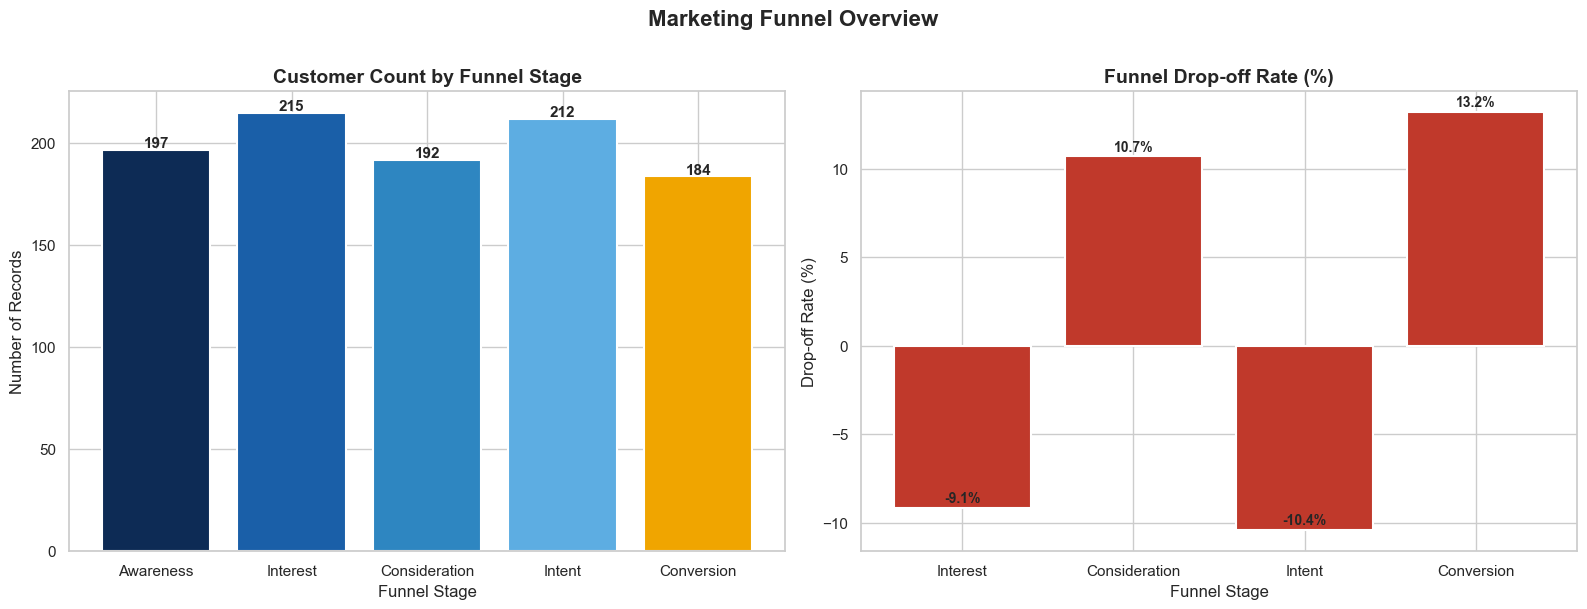

Chart saved as funnel_analysis.png


In [12]:
# CHART 1 — Funnel Stage Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#0d2b55', '#1a5fa8', '#2e86c1', '#5dade2', '#f0a500']

# Bar chart
bars = axes[0].bar(funnel['Funnel_Stage'], funnel['Total_Records'],
                   color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Customer Count by Funnel Stage', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Funnel Stage')
axes[0].set_ylabel('Number of Records')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')

# Drop-off rate
drop = funnel[funnel['Drop_Off_%'] != 0]
axes[1].bar(drop['Funnel_Stage'], drop['Drop_Off_%'],
            color='#c0392b', edgecolor='white', linewidth=1.5)
axes[1].set_title('Funnel Drop-off Rate (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Funnel Stage')
axes[1].set_ylabel('Drop-off Rate (%)')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Marketing Funnel Overview', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('funnel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as funnel_analysis.png')


---
## 5. Conversion Rate Analysis <a id='5'></a>

> Analyse conversion rates across channels, campaigns, and customer segments.


In [13]:
# Overall Conversion Rate
total_clicks    = df['Clicks'].sum()
total_purchases = df['Purchases'].sum()
overall_cr      = round(total_purchases / total_clicks * 100, 2)

print('=== Overall Conversion Metrics ===')
print(f'Total Clicks        : {total_clicks:,}')
print(f'Total Purchases     : {total_purchases:,}')
print(f'Overall Conv. Rate  : {overall_cr}%')
print(f'Avg Conv. Rate      : {df["Conversion_Rate"].mean():.2f}%')
print(f'Max Conv. Rate      : {df["Conversion_Rate"].max():.2f}%')


=== Overall Conversion Metrics ===
Total Clicks        : 1,979,689
Total Purchases     : 22,876
Overall Conv. Rate  : 1.16%
Avg Conv. Rate      : 1.07%
Max Conv. Rate      : 4.57%


In [14]:
# Conversion Rate by Channel
cr_channel = df.groupby('Campaign_Channel').agg(
    Clicks     = ('Clicks', 'sum'),
    Purchases  = ('Purchases', 'sum'),
    Avg_CR     = ('Conversion_Rate', 'mean')
).assign(Actual_CR=lambda x: (x['Purchases']/x['Clicks']*100).round(2))
cr_channel['Avg_CR'] = cr_channel['Avg_CR'].round(2)
cr_channel = cr_channel.sort_values('Avg_CR', ascending=False)
print('=== Conversion Rate by Channel ===')
print(cr_channel)


=== Conversion Rate by Channel ===
                  Clicks  Purchases  Avg_CR  Actual_CR
Campaign_Channel                                      
Google            427990       5100    1.10       1.19
YouTube           411634       4921    1.09       1.20
Instagram         356385       4135    1.09       1.16
Email             381749       4075    1.04       1.07
Facebook          401931       4645    1.00       1.16


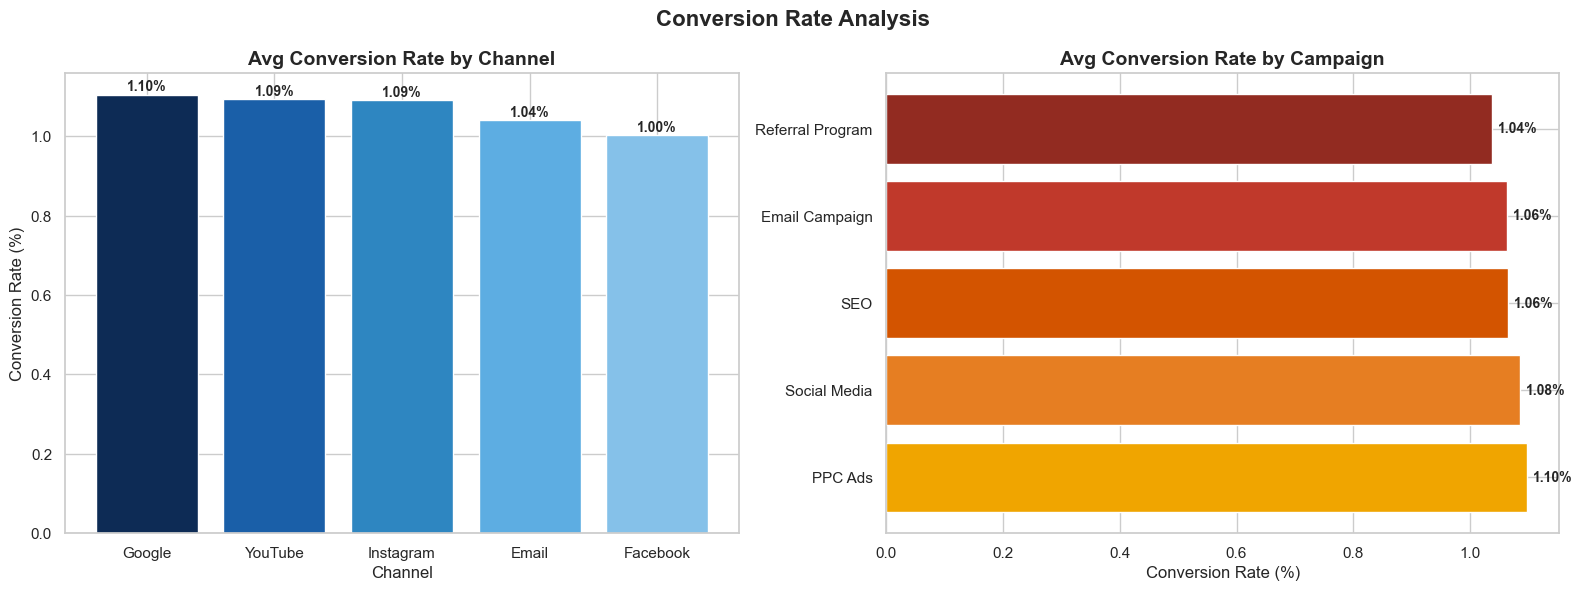

In [15]:
# CHART 2 — Conversion Rate by Channel & Campaign
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By channel
cr_ch = df.groupby('Campaign_Channel')['Conversion_Rate'].mean().sort_values(ascending=False)
axes[0].bar(cr_ch.index, cr_ch.values,
            color=['#0d2b55','#1a5fa8','#2e86c1','#5dade2','#85c1e9'],
            edgecolor='white')
axes[0].set_title('Avg Conversion Rate by Channel', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_xlabel('Channel')
for i, v in enumerate(cr_ch.values):
    axes[0].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')

# By campaign
cr_camp = df.groupby('Campaign_Name')['Conversion_Rate'].mean().sort_values(ascending=False)
axes[1].barh(cr_camp.index, cr_camp.values,
             color=['#f0a500','#e67e22','#d35400','#c0392b','#922b21'])
axes[1].set_title('Avg Conversion Rate by Campaign', fontweight='bold')
axes[1].set_xlabel('Conversion Rate (%)')
for i, v in enumerate(cr_camp.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Conversion Rate Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('conversion_rate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. ROI & Ad Spend Analysis <a id='6'></a>

> Evaluate return on investment and advertising spend efficiency across channels and campaigns.


In [16]:
# Overall Financial Summary
total_revenue   = df['Revenue'].sum()
total_ad_spend  = df['Ad_Spend'].sum()
overall_roi     = (total_revenue - total_ad_spend) / total_ad_spend * 100
total_purchases = df['Purchases'].sum()

print('=== Overall Financial Summary ===')
print(f'Total Revenue   : ${total_revenue:,.2f}')
print(f'Total Ad Spend  : ${total_ad_spend:,.2f}')
print(f'Net Profit      : ${(total_revenue - total_ad_spend):,.2f}')
print(f'Overall ROI     : {overall_roi:.2f}%')
print(f'Total Purchases : {total_purchases:,}')
print(f'Avg Order Value : ${(total_revenue/total_purchases if total_purchases>0 else 0):.2f}')


=== Overall Financial Summary ===
Total Revenue   : $6,383,232.65
Total Ad Spend  : $2,479,813.73
Net Profit      : $3,903,418.92
Overall ROI     : 157.41%
Total Purchases : 22,876
Avg Order Value : $279.04


In [17]:
# ROI & Ad Spend by Channel
roi_channel = df.groupby('Campaign_Channel').agg(
    Ad_Spend  = ('Ad_Spend', 'sum'),
    Revenue   = ('Revenue', 'sum'),
    Avg_ROI   = ('ROI', 'mean')
).round(2)
roi_channel['ROAS'] = (roi_channel['Revenue'] / roi_channel['Ad_Spend']).round(2)
roi_channel = roi_channel.sort_values('Avg_ROI', ascending=False)
print('=== ROI & ROAS by Channel ===')
print(roi_channel)


=== ROI & ROAS by Channel ===
                   Ad_Spend     Revenue  Avg_ROI  ROAS
Campaign_Channel                                      
Google            491980.29  1540092.79   549.08  3.13
Email             458915.61  1094267.67   413.98  2.38
YouTube           514811.54  1369991.77   400.39  2.66
Facebook          498959.41  1361916.58   327.54  2.73
Instagram         515146.88  1016963.84   262.10  1.97


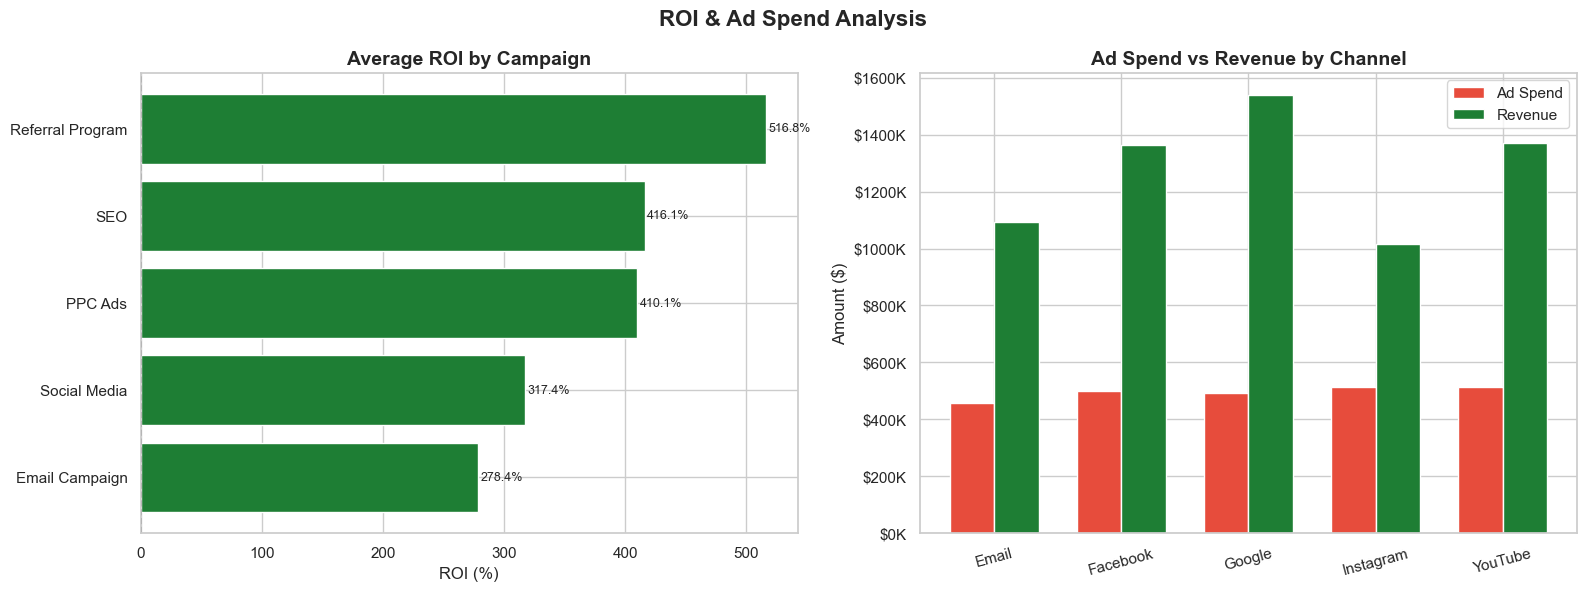

In [18]:
# CHART 3 — ROI by Campaign & Channel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROI by campaign
roi_camp = df.groupby('Campaign_Name')['ROI'].mean().sort_values()
bar_colors = ['#1e7e34' if x >= 0 else '#c0392b' for x in roi_camp.values]
axes[0].barh(roi_camp.index, roi_camp.values, color=bar_colors, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=1.2, linestyle='--')
axes[0].set_title('Average ROI by Campaign', fontweight='bold')
axes[0].set_xlabel('ROI (%)')
for i, v in enumerate(roi_camp.values):
    axes[0].text(v + 2, i, f'{v:.1f}%', va='center', fontsize=9)

# Ad Spend vs Revenue by channel
spend_rev = df.groupby('Campaign_Channel')[['Ad_Spend','Revenue']].sum()
x = np.arange(len(spend_rev))
width = 0.35
axes[1].bar(x - width/2, spend_rev['Ad_Spend'], width, label='Ad Spend',
            color='#e74c3c', edgecolor='white')
axes[1].bar(x + width/2, spend_rev['Revenue'], width, label='Revenue',
            color='#1e7e34', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(spend_rev.index, rotation=15)
axes[1].set_title('Ad Spend vs Revenue by Channel', fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('ROI & Ad Spend Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('roi_adspend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Channel Performance Analysis <a id='7'></a>

> Full performance comparison across all marketing channels.


In [19]:
# Comprehensive Channel Performance Table
channel_perf = df.groupby('Campaign_Channel').agg(
    Impressions   = ('Impressions', 'sum'),
    Clicks        = ('Clicks', 'sum'),
    Leads         = ('Leads_Generated', 'sum'),
    Sign_Ups      = ('Sign_Ups', 'sum'),
    Purchases     = ('Purchases', 'sum'),
    Revenue       = ('Revenue', 'sum'),
    Ad_Spend      = ('Ad_Spend', 'sum'),
    Avg_CPC       = ('Cost_Per_Click', 'mean'),
    Avg_ROI       = ('ROI', 'mean')
).round(2)

channel_perf['CTR_%']  = (channel_perf['Clicks'] / channel_perf['Impressions'] * 100).round(2)
channel_perf['ROAS']   = (channel_perf['Revenue'] / channel_perf['Ad_Spend']).round(2)
channel_perf['CR_%']   = (channel_perf['Purchases'] / channel_perf['Clicks'] * 100).round(2)

channel_perf = channel_perf.sort_values('Revenue', ascending=False)
print('=== Full Channel Performance ===')
print(channel_perf[['Impressions','Clicks','CTR_%','Purchases','CR_%',
                     'Revenue','Ad_Spend','Avg_CPC','ROAS','Avg_ROI']].to_string())


=== Full Channel Performance ===
                  Impressions  Clicks  CTR_%  Purchases  CR_%     Revenue   Ad_Spend  Avg_CPC  ROAS  Avg_ROI
Campaign_Channel                                                                                            
Google                5184435  427990   8.26       5100  1.19  1540092.79  491980.29     5.70  3.13   549.08
YouTube               5071536  411634   8.12       4921  1.20  1369991.77  514811.54     4.57  2.66   400.39
Facebook              4878110  401931   8.24       4645  1.16  1361916.58  498959.41     4.68  2.73   327.54
Email                 4774933  381749   7.99       4075  1.07  1094267.67  458915.61     3.19  2.38   413.98
Instagram             4921882  356385   7.24       4135  1.16  1016963.84  515146.88     5.21  1.97   262.10


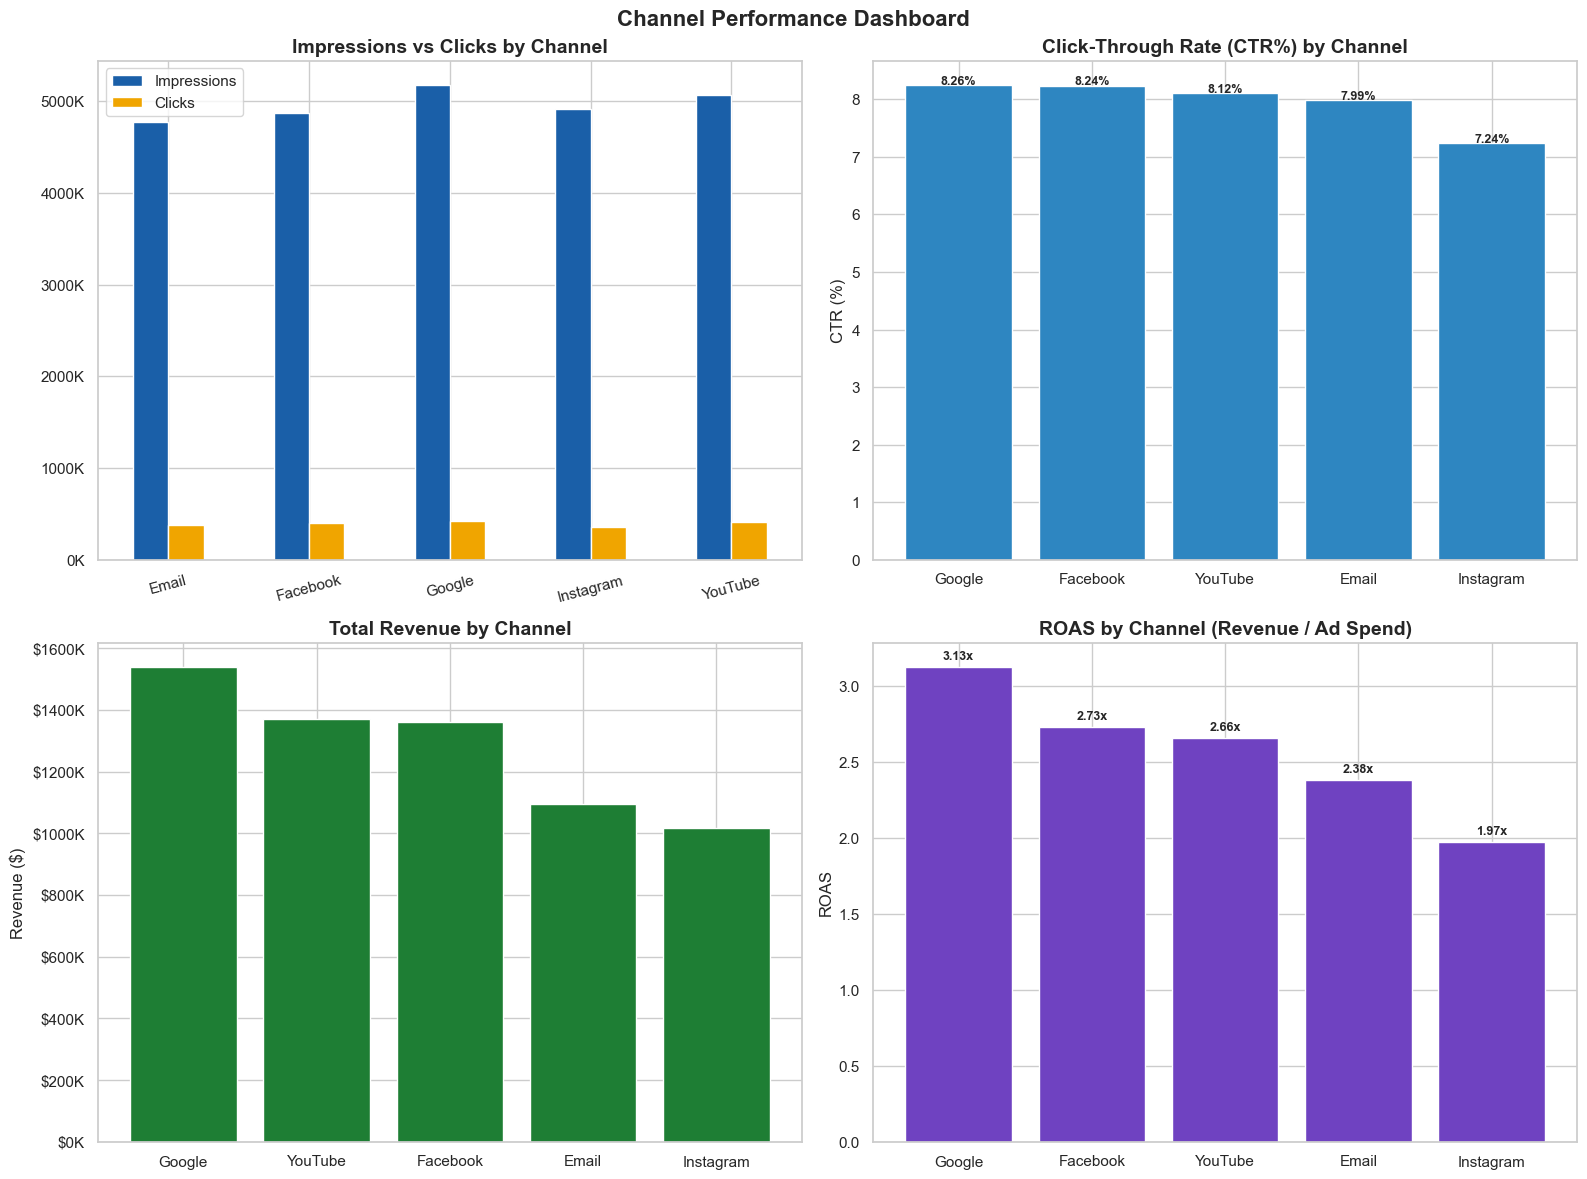

In [20]:
# CHART 4 — Channel Performance Grouped Bar
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ch = df.groupby('Campaign_Channel')

# Impressions vs Clicks
imp_click = ch[['Impressions','Clicks']].sum()
imp_click.plot(kind='bar', ax=axes[0,0], color=['#1a5fa8','#f0a500'], edgecolor='white')
axes[0,0].set_title('Impressions vs Clicks by Channel', fontweight='bold')
axes[0,0].set_xlabel(''); axes[0,0].tick_params(axis='x', rotation=15)
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# CTR
ctr = (ch['Clicks'].sum() / ch['Impressions'].sum() * 100).sort_values(ascending=False)
axes[0,1].bar(ctr.index, ctr.values, color='#2e86c1', edgecolor='white')
axes[0,1].set_title('Click-Through Rate (CTR%) by Channel', fontweight='bold')
axes[0,1].set_ylabel('CTR (%)')
for i,v in enumerate(ctr.values):
    axes[0,1].text(i, v+0.01, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')

# Revenue
rev = ch['Revenue'].sum().sort_values(ascending=False)
axes[1,0].bar(rev.index, rev.values, color='#1e7e34', edgecolor='white')
axes[1,0].set_title('Total Revenue by Channel', fontweight='bold')
axes[1,0].set_ylabel('Revenue ($)')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

# ROAS
roas = (ch['Revenue'].sum() / ch['Ad_Spend'].sum()).sort_values(ascending=False)
axes[1,1].bar(roas.index, roas.values, color='#6f42c1', edgecolor='white')
axes[1,1].set_title('ROAS by Channel (Revenue / Ad Spend)', fontweight='bold')
axes[1,1].set_ylabel('ROAS')
for i,v in enumerate(roas.values):
    axes[1,1].text(i, v+0.05, f'{v:.2f}x', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Channel Performance Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('channel_performance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Campaign Performance Analysis <a id='8'></a>


In [21]:
# Campaign Performance Summary
camp_perf = df.groupby('Campaign_Name').agg(
    Records      = ('Customer_ID', 'count'),
    Impressions  = ('Impressions', 'sum'),
    Clicks       = ('Clicks', 'sum'),
    Purchases    = ('Purchases', 'sum'),
    Revenue      = ('Revenue', 'sum'),
    Ad_Spend     = ('Ad_Spend', 'sum'),
    Avg_CR       = ('Conversion_Rate', 'mean'),
    Avg_ROI      = ('ROI', 'mean')
).round(2).sort_values('Revenue', ascending=False)

camp_perf['ROI_%'] = ((camp_perf['Revenue'] - camp_perf['Ad_Spend']) /
                       camp_perf['Ad_Spend'] * 100).round(2)

print('=== Campaign Performance Summary ===')
print(camp_perf.to_string())


=== Campaign Performance Summary ===
                  Records  Impressions  Clicks  Purchases     Revenue   Ad_Spend  Avg_CR  Avg_ROI   ROI_%
Campaign_Name                                                                                            
SEO                   218      5226652  433022       5186  1464653.94  543138.48    1.06   416.07  169.66
Referral Program      214      5461683  435372       4797  1383514.01  524581.35    1.04   516.79  163.74
Email Campaign        193      5037738  391844       4549  1222470.31  505286.02    1.06   278.42  141.94
PPC Ads               188      4631583  378447       4259  1203523.34  464299.64    1.10   410.10  159.21
Social Media          187      4473240  341004       4085  1109071.05  442508.24    1.08   317.45  150.63


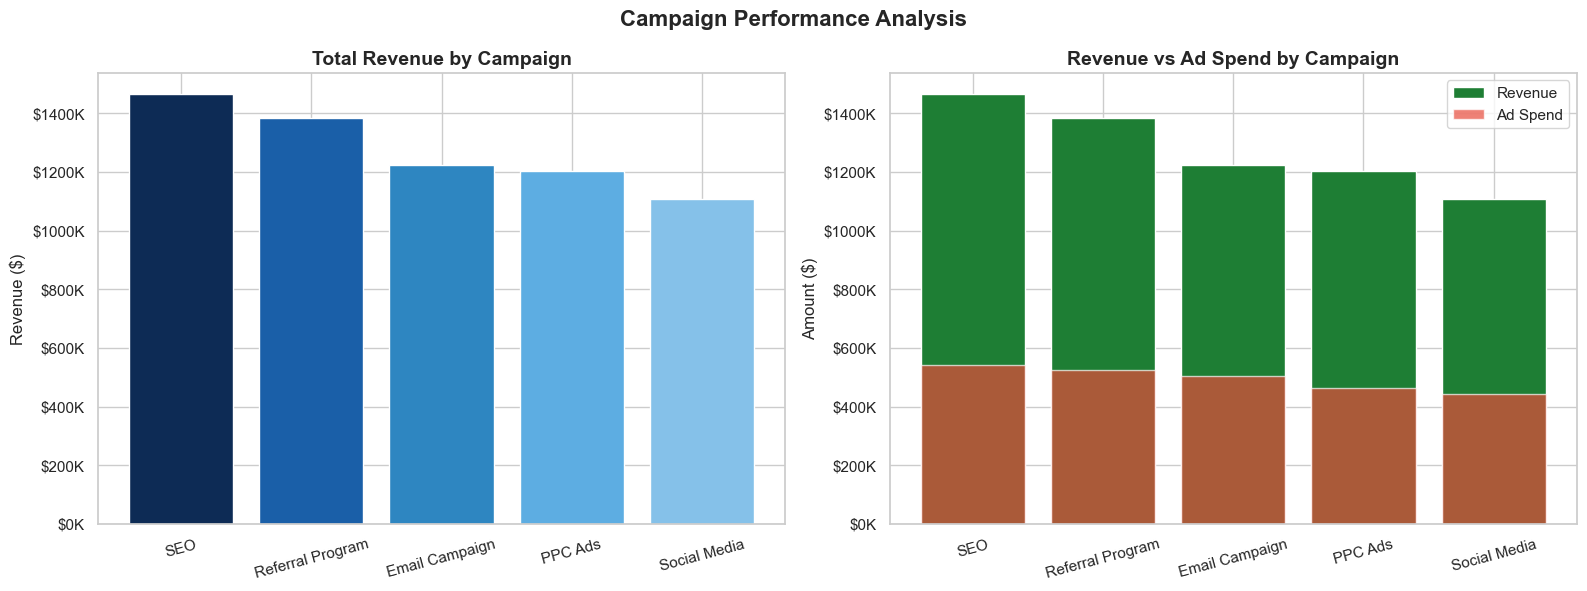

In [22]:
# CHART 5 — Campaign Revenue & ROI
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by campaign
rev_camp = df.groupby('Campaign_Name')['Revenue'].sum().sort_values(ascending=False)
axes[0].bar(rev_camp.index, rev_camp.values,
            color=['#0d2b55','#1a5fa8','#2e86c1','#5dade2','#85c1e9'],
            edgecolor='white')
axes[0].set_title('Total Revenue by Campaign', fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

# Stacked: Ad Spend vs Revenue
camp_data = df.groupby('Campaign_Name')[['Ad_Spend','Revenue']].sum().sort_values('Revenue', ascending=False)
x = np.arange(len(camp_data))
axes[1].bar(x, camp_data['Revenue'], label='Revenue', color='#1e7e34', edgecolor='white')
axes[1].bar(x, camp_data['Ad_Spend'], label='Ad Spend', color='#e74c3c',
            alpha=0.7, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(camp_data.index, rotation=15)
axes[1].set_title('Revenue vs Ad Spend by Campaign', fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

plt.suptitle('Campaign Performance Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('campaign_performance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Customer Segment Analysis <a id='9'></a>


In [23]:
# Segment Performance
seg_perf = df.groupby('Customer_Segment').agg(
    Records      = ('Customer_ID', 'count'),
    Clicks       = ('Clicks', 'sum'),
    Purchases    = ('Purchases', 'sum'),
    Revenue      = ('Revenue', 'sum'),
    Ad_Spend     = ('Ad_Spend', 'sum'),
    Avg_CR       = ('Conversion_Rate', 'mean'),
    Avg_ROI      = ('ROI', 'mean')
).round(2).sort_values('Revenue', ascending=False)

print('=== Customer Segment Performance ===')
print(seg_perf)


=== Customer Segment Performance ===
                  Records  Clicks  Purchases     Revenue   Ad_Spend  Avg_CR  \
Customer_Segment                                                              
Premium               343  679019       7867  2303400.23  835244.28    1.11   
New                   328  682724       7849  2211527.78  807104.83    1.06   
Returning             329  617946       7160  1868304.64  837464.62    1.03   

                  Avg_ROI  
Customer_Segment           
Premium            421.33  
New                448.62  
Returning          303.43  


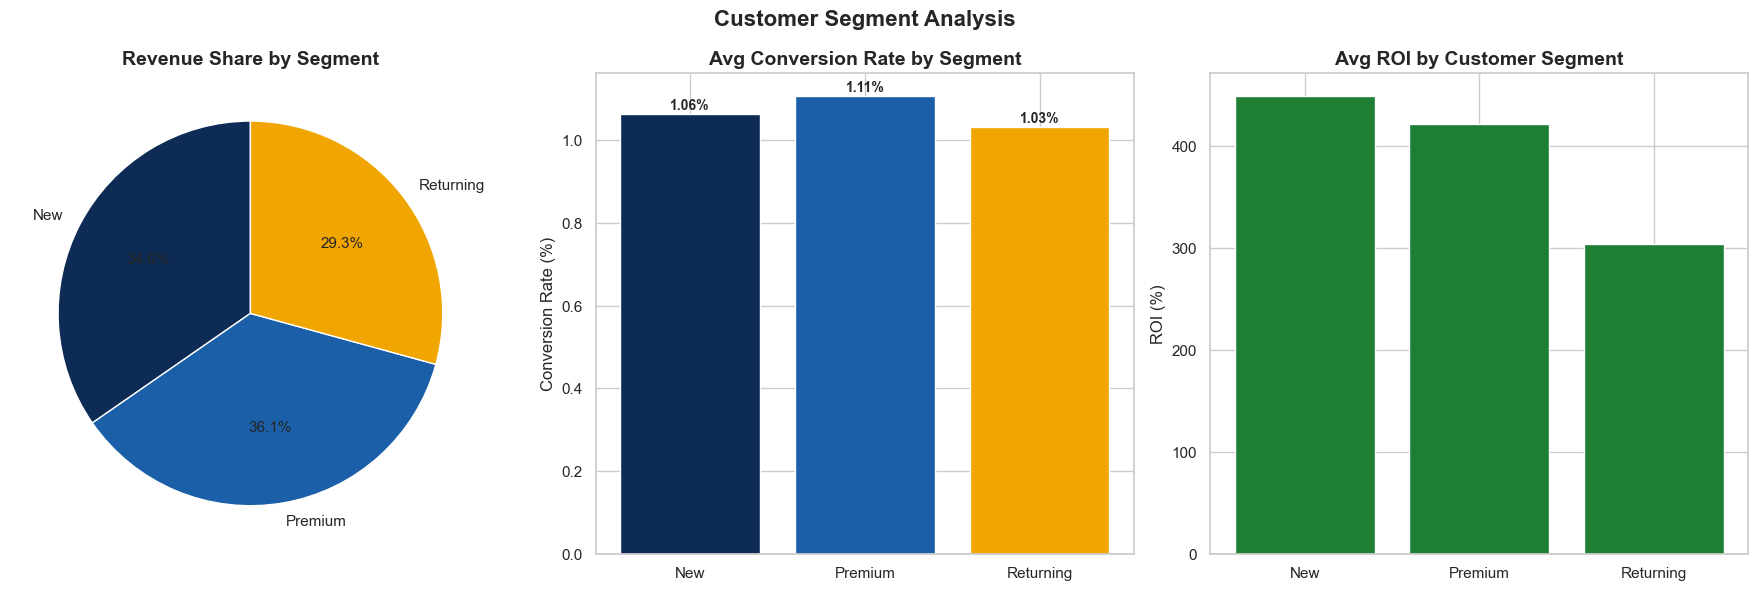

In [24]:
# CHART 6 — Segment Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

seg_rev = df.groupby('Customer_Segment')['Revenue'].sum()
seg_cr  = df.groupby('Customer_Segment')['Conversion_Rate'].mean()
seg_roi = df.groupby('Customer_Segment')['ROI'].mean()

# Revenue pie
axes[0].pie(seg_rev, labels=seg_rev.index, autopct='%1.1f%%',
            colors=['#0d2b55','#1a5fa8','#f0a500'], startangle=90)
axes[0].set_title('Revenue Share by Segment', fontweight='bold')

# Conversion rate bar
axes[1].bar(seg_cr.index, seg_cr.values,
            color=['#0d2b55','#1a5fa8','#f0a500'], edgecolor='white')
axes[1].set_title('Avg Conversion Rate by Segment', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
for i,v in enumerate(seg_cr.values):
    axes[1].text(i, v+0.01, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')

# ROI bar
bar_colors = ['#1e7e34' if x>=0 else '#c0392b' for x in seg_roi.values]
axes[2].bar(seg_roi.index, seg_roi.values, color=bar_colors, edgecolor='white')
axes[2].set_title('Avg ROI by Customer Segment', fontweight='bold')
axes[2].set_ylabel('ROI (%)')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.suptitle('Customer Segment Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Device & Region Analysis <a id='10'></a>


In [25]:
# Device Performance
dev_perf = df.groupby('Device').agg(
    Records      = ('Customer_ID', 'count'),
    Clicks       = ('Clicks', 'sum'),
    Purchases    = ('Purchases', 'sum'),
    Revenue      = ('Revenue', 'sum'),
    Avg_CR       = ('Conversion_Rate', 'mean')
).round(2).sort_values('Revenue', ascending=False)

print('=== Device Performance ===')
print(dev_perf)

# Region Performance
reg_perf = df.groupby('Region').agg(
    Records      = ('Customer_ID', 'count'),
    Revenue      = ('Revenue', 'sum'),
    Ad_Spend     = ('Ad_Spend', 'sum'),
    Avg_ROI      = ('ROI', 'mean')
).round(2).sort_values('Revenue', ascending=False)

print('\n=== Region Performance ===')
print(reg_perf)


=== Device Performance ===
         Records  Clicks  Purchases     Revenue  Avg_CR
Device                                                 
Tablet       334  694484       8647  2453217.21    1.15
Desktop      327  664054       7522  2083712.85    1.07
Mobile       339  621151       6707  1846302.59    0.98

=== Region Performance ===
        Records     Revenue   Ad_Spend  Avg_ROI
Region                                         
North       248  1700129.18  604309.83   378.84
East        265  1669570.92  645266.45   340.57
South       247  1630885.46  614019.48   432.48
West        240  1382647.09  616217.97   418.61


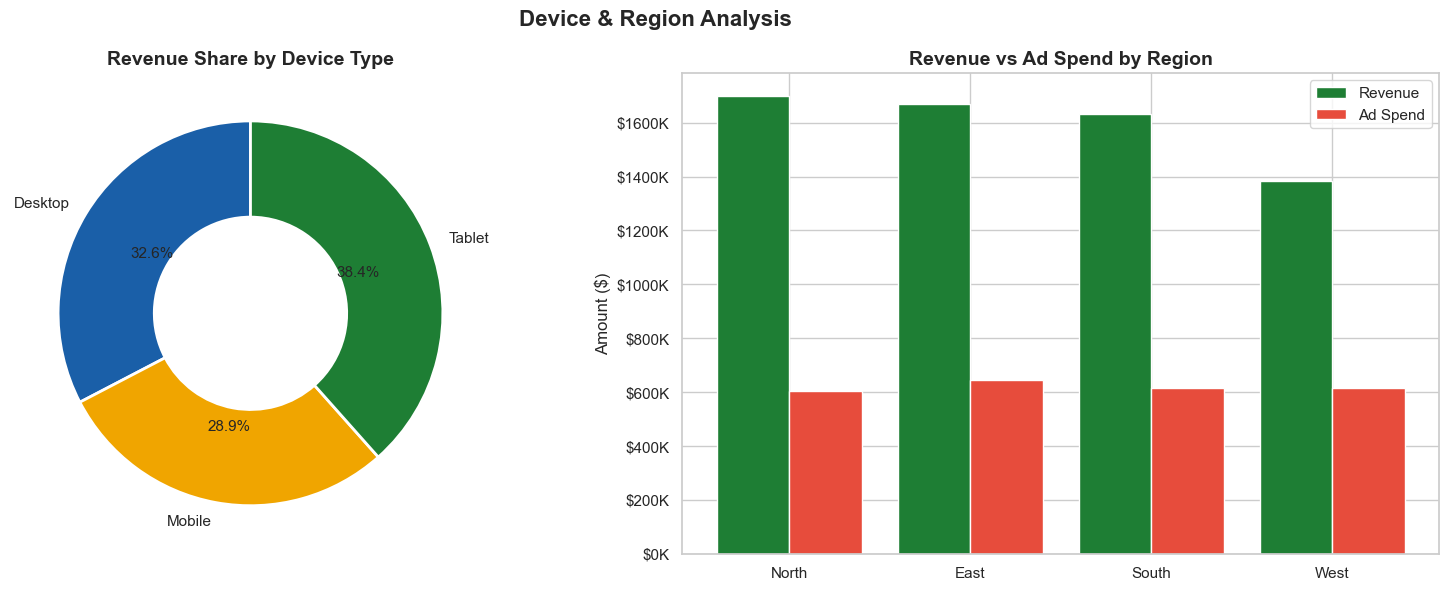

In [26]:
# CHART 7 — Device & Region
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Device donut
dev_rev = df.groupby('Device')['Revenue'].sum()
wedge_props = dict(width=0.5, edgecolor='white', linewidth=2)
axes[0].pie(dev_rev, labels=dev_rev.index, autopct='%1.1f%%',
            wedgeprops=wedge_props,
            colors=['#1a5fa8','#f0a500','#1e7e34'], startangle=90)
axes[0].set_title('Revenue Share by Device Type', fontweight='bold')

# Region grouped bar
reg_data = df.groupby('Region')[['Revenue','Ad_Spend']].sum().sort_values('Revenue', ascending=False)
x = np.arange(len(reg_data))
axes[1].bar(x-0.2, reg_data['Revenue'], 0.4, label='Revenue', color='#1e7e34', edgecolor='white')
axes[1].bar(x+0.2, reg_data['Ad_Spend'], 0.4, label='Ad Spend', color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(reg_data.index)
axes[1].set_title('Revenue vs Ad Spend by Region', fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

plt.suptitle('Device & Region Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('device_region_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 11. Time Series / Monthly Trend Analysis <a id='11'></a>


In [27]:
# Monthly Aggregation
monthly = df.groupby('Month').agg(
    Impressions  = ('Impressions', 'sum'),
    Clicks       = ('Clicks', 'sum'),
    Purchases    = ('Purchases', 'sum'),
    Revenue      = ('Revenue', 'sum'),
    Ad_Spend     = ('Ad_Spend', 'sum'),
    Avg_CR       = ('Conversion_Rate', 'mean')
).round(2).reset_index().sort_values('Month')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
monthly['Month_Name'] = monthly['Month'].apply(lambda x: month_labels[x-1])

print('=== Monthly Performance ===')
print(monthly[['Month_Name','Clicks','Purchases','Revenue','Ad_Spend','Avg_CR']].to_string(index=False))


=== Monthly Performance ===
Month_Name  Clicks  Purchases   Revenue  Ad_Spend  Avg_CR
       Jan  135390       1603 447999.10 193518.96    1.09
       Feb  194710       2570 762573.80 232219.03    1.17
       Mar  145853       1686 425468.49 171600.33    1.06
       Apr  150286       1672 427961.05 213134.49    1.01
       May  219941       2405 585616.30 265875.40    1.00
       Jun  163229       1900 543184.82 192742.08    1.19
       Jul  138193       1613 446383.90 165442.21    1.16
       Aug  175167       1886 504434.13 235665.82    0.97
       Sep  128495       1466 424280.74 160546.11    1.08
       Oct  201395       2461 815844.13 227065.98    1.04
       Nov  159276       1717 443886.30 190924.17    1.14
       Dec  167754       1897 555599.89 231079.15    0.98


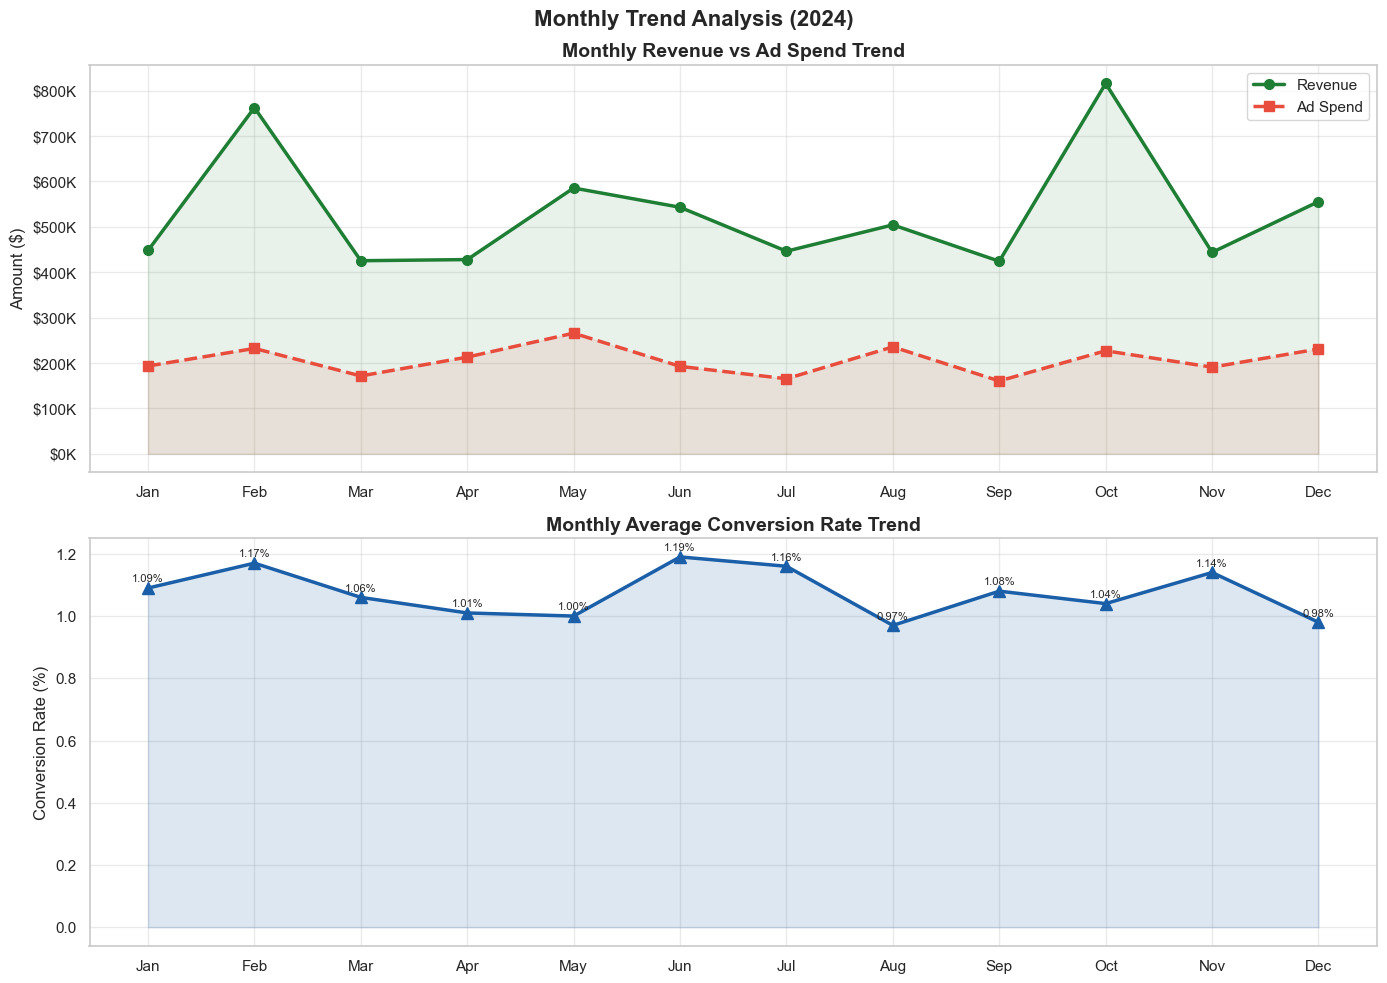

In [28]:
# CHART 8 — Monthly Trends
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

x = monthly['Month_Name']

# Revenue & Ad Spend trend
axes[0].plot(x, monthly['Revenue'], marker='o', color='#1e7e34',
             linewidth=2.5, markersize=7, label='Revenue')
axes[0].plot(x, monthly['Ad_Spend'], marker='s', color='#e74c3c',
             linewidth=2.5, markersize=7, label='Ad Spend', linestyle='--')
axes[0].fill_between(x, monthly['Revenue'], alpha=0.1, color='#1e7e34')
axes[0].fill_between(x, monthly['Ad_Spend'], alpha=0.1, color='#e74c3c')
axes[0].set_title('Monthly Revenue vs Ad Spend Trend', fontweight='bold')
axes[0].set_ylabel('Amount ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].grid(True, alpha=0.4)

# Conversion rate trend
axes[1].plot(x, monthly['Avg_CR'], marker='^', color='#1a5fa8',
             linewidth=2.5, markersize=8, label='Avg Conversion Rate')
axes[1].fill_between(x, monthly['Avg_CR'], alpha=0.15, color='#1a5fa8')
axes[1].set_title('Monthly Average Conversion Rate Trend', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].grid(True, alpha=0.4)
for i, v in enumerate(monthly['Avg_CR']):
    axes[1].text(i, v+0.02, f'{v:.2f}%', ha='center', fontsize=8)

plt.suptitle('Monthly Trend Analysis (2024)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 12. Scatter Plot & Correlation Heatmap <a id='12'></a>


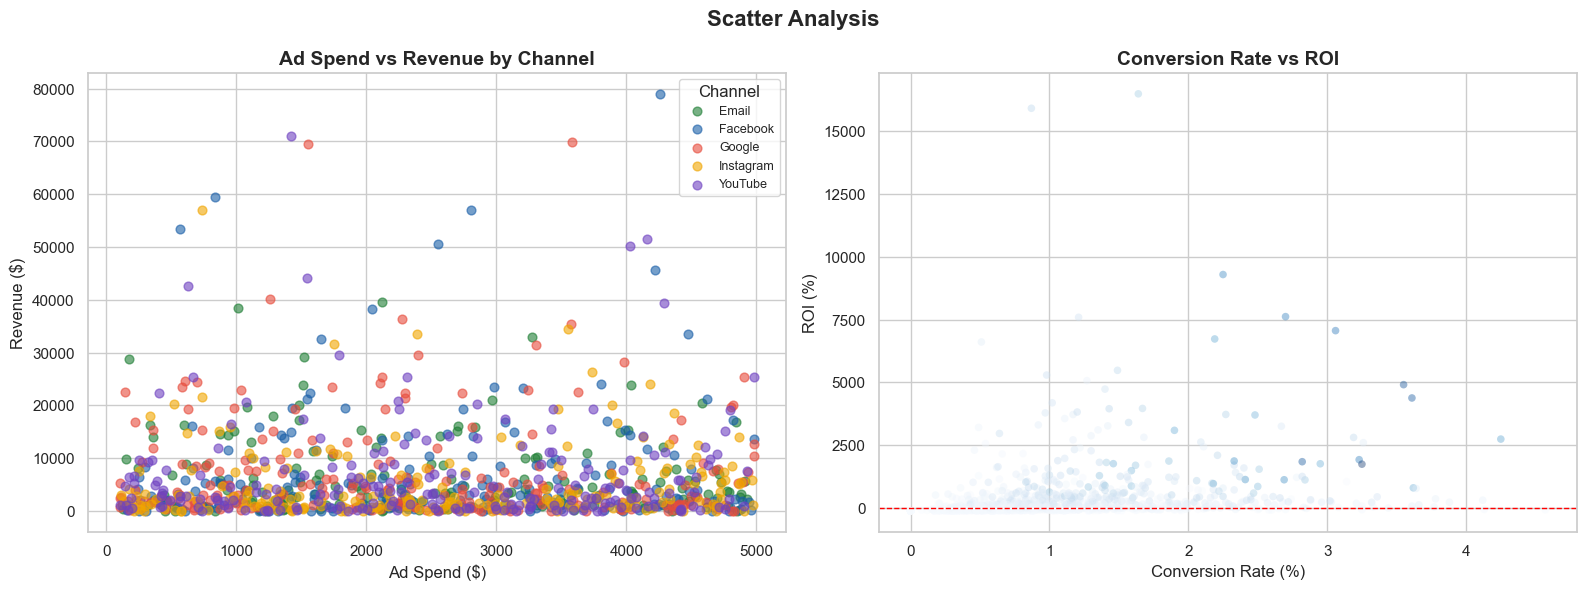

In [29]:
# CHART 9 — Ad Spend vs Revenue Scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

channel_colors = {'Facebook':'#1a5fa8','Google':'#e74c3c',
                   'Email':'#1e7e34','Instagram':'#f0a500','YouTube':'#6f42c1'}

for channel, grp in df.groupby('Campaign_Channel'):
    axes[0].scatter(grp['Ad_Spend'], grp['Revenue'],
                    label=channel, alpha=0.6, s=40,
                    color=channel_colors.get(channel, 'grey'))

axes[0].set_title('Ad Spend vs Revenue by Channel', fontweight='bold')
axes[0].set_xlabel('Ad Spend ($)')
axes[0].set_ylabel('Revenue ($)')
axes[0].legend(title='Channel', fontsize=9)

# Conversion Rate vs ROI
axes[1].scatter(df['Conversion_Rate'], df['ROI'],
                alpha=0.4, s=30, c=df['Revenue'],
                cmap='Blues', edgecolors='none')
axes[1].set_title('Conversion Rate vs ROI', fontweight='bold')
axes[1].set_xlabel('Conversion Rate (%)')
axes[1].set_ylabel('ROI (%)')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.suptitle('Scatter Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


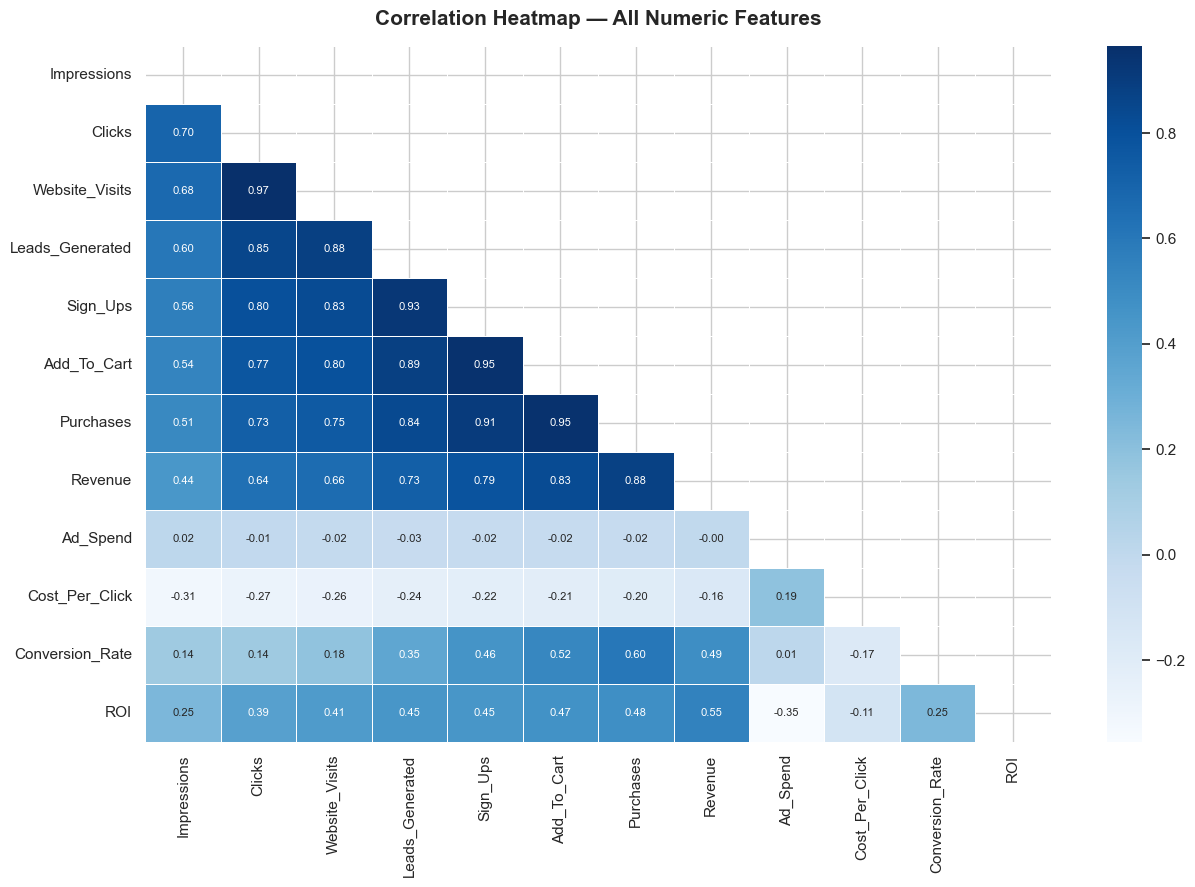


=== Top Correlations with Revenue ===
Purchases          0.880
Add_To_Cart        0.829
Sign_Ups           0.789
Leads_Generated    0.728
Website_Visits     0.659
Clicks             0.640
ROI                0.549
Conversion_Rate    0.487
Impressions        0.443
Ad_Spend          -0.003
Cost_Per_Click    -0.161
Name: Revenue, dtype: float64


In [30]:
# CHART 10 — Correlation Heatmap
numeric_cols = ['Impressions','Clicks','Website_Visits','Leads_Generated',
                'Sign_Ups','Add_To_Cart','Purchases','Revenue',
                'Ad_Spend','Cost_Per_Click','Conversion_Rate','ROI']

corr = df[numeric_cols].corr()

plt.figure(figsize=(13, 9))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, mask=mask,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — All Numeric Features',
          fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with Revenue
print('\n=== Top Correlations with Revenue ===')
print(corr['Revenue'].drop('Revenue').sort_values(ascending=False).round(3))


---
## 13. Key Insights & Business Summary <a id='13'></a>


In [31]:
# === FINAL SUMMARY DASHBOARD ===
print('=' * 55)
print('   MARKETING FUNNEL — FINAL SUMMARY REPORT')
print('=' * 55)

total_rev   = df['Revenue'].sum()
total_spend = df['Ad_Spend'].sum()
total_pur   = df['Purchases'].sum()
total_clicks= df['Clicks'].sum()
overall_roi = (total_rev - total_spend) / total_spend * 100
avg_cr      = df['Conversion_Rate'].mean()

print(f'  Total Revenue        : ${total_rev:>15,.2f}')
print(f'  Total Ad Spend       : ${total_spend:>15,.2f}')
print(f'  Net Profit           : ${(total_rev-total_spend):>15,.2f}')
print(f'  Overall ROI          : {overall_roi:>15.2f}%')
print(f'  Total Purchases      : {total_pur:>16,}')
print(f'  Total Clicks         : {total_clicks:>16,}')
print(f'  Avg Conversion Rate  : {avg_cr:>15.2f}%')
print('-' * 55)

best_ch  = df.groupby('Campaign_Channel')['ROI'].mean().idxmax()
best_cp  = df.groupby('Campaign_Name')['Revenue'].sum().idxmax()
best_seg = df.groupby('Customer_Segment')['Revenue'].sum().idxmax()
best_dev = df.groupby('Device')['Revenue'].sum().idxmax()
best_reg = df.groupby('Region')['Revenue'].sum().idxmax()
best_stg = df.groupby('Funnel_Stage')['Purchases'].sum().idxmax()

print(f'  Best Channel (ROI)   : {best_ch}')
print(f'  Best Campaign (Rev)  : {best_cp}')
print(f'  Best Segment         : {best_seg}')
print(f'  Best Device          : {best_dev}')
print(f'  Best Region          : {best_reg}')
print(f'  Best Funnel Stage    : {best_stg}')
print('=' * 55)


   MARKETING FUNNEL — FINAL SUMMARY REPORT
  Total Revenue        : $   6,383,232.65
  Total Ad Spend       : $   2,479,813.73
  Net Profit           : $   3,903,418.92
  Overall ROI          :          157.41%
  Total Purchases      :           22,876
  Total Clicks         :        1,979,689
  Avg Conversion Rate  :            1.07%
-------------------------------------------------------
  Best Channel (ROI)   : Google
  Best Campaign (Rev)  : SEO
  Best Segment         : Premium
  Best Device          : Tablet
  Best Region          : North
  Best Funnel Stage    : Intent


### 📌 Business Recommendations

Based on the analysis above, here are the key recommendations:

1. **Focus budget on top-performing channels** — Allocate more ad spend to channels with highest ROI and ROAS.
2. **Reduce funnel drop-off** — Improve mid-funnel content (Interest → Consideration stage) to retain more potential customers.
3. **Prioritise high-value segments** — Target Premium and Returning customers who show higher conversion rates.
4. **Optimise for mobile** — If Mobile drives highest revenue, ensure all campaigns are mobile-optimised.
5. **Scale best campaigns** — Increase budget for campaigns with the best revenue and ROI performance.
6. **Seasonal targeting** — Use monthly trend data to run campaigns during peak conversion months.


---
## 14. Export Results to CSV <a id='14'></a>


In [32]:
import json

# Compile all key results
results = {
    'overall_performance': {
        'Total_Revenue'       : round(df['Revenue'].sum(), 2),
        'Total_Ad_Spend'      : round(df['Ad_Spend'].sum(), 2),
        'Net_Profit'          : round(df['Revenue'].sum() - df['Ad_Spend'].sum(), 2),
        'Overall_ROI_%'       : round((df['Revenue'].sum()-df['Ad_Spend'].sum())
                                       / df['Ad_Spend'].sum()*100, 2),
        'Total_Purchases'     : int(df['Purchases'].sum()),
        'Avg_Conversion_Rate' : round(df['Conversion_Rate'].mean(), 2),
    },
    'best_channel_by_roi'     : df.groupby('Campaign_Channel')['ROI'].mean().idxmax(),
    'best_campaign_by_revenue': df.groupby('Campaign_Name')['Revenue'].sum().idxmax(),
    'best_customer_segment'   : df.groupby('Customer_Segment')['Revenue'].sum().idxmax(),
    'best_device'             : df.groupby('Device')['Revenue'].sum().idxmax(),
    'best_region'             : df.groupby('Region')['Revenue'].sum().idxmax(),
    'funnel_stage_counts'     : df['Funnel_Stage'].value_counts().to_dict(),
    'channel_roi'             : df.groupby('Campaign_Channel')['ROI'].mean().round(2).to_dict(),
    'campaign_revenue'        : df.groupby('Campaign_Name')['Revenue'].sum().round(2).to_dict(),
}

results_df = pd.DataFrame([
    {'metric': k, 'value': json.dumps(v) if isinstance(v, dict) else str(v)}
    for k, v in results.items()
])

results_df.to_csv('marketing_funnel_results.csv', index=False)
print('✅ Results exported to marketing_funnel_results.csv')
print(results_df.to_string(index=False))


✅ Results exported to marketing_funnel_results.csv
                  metric                                                                                                                                                                 value
     overall_performance {"Total_Revenue": 6383232.65, "Total_Ad_Spend": 2479813.73, "Net_Profit": 3903418.92, "Overall_ROI_%": 157.41, "Total_Purchases": 22876, "Avg_Conversion_Rate": 1.07}
     best_channel_by_roi                                                                                                                                                                Google
best_campaign_by_revenue                                                                                                                                                                   SEO
   best_customer_segment                                                                                                                                                               Pr

---

## ✅ Analysis Complete!

| File | Description |
|------|-------------|
| `EDA_marketing_funnel.ipynb` | This notebook — full EDA |
| `Marketing_Funnel_Dataset.csv` | Source dataset (1000 rows) |
| `marketing_funnel_results.csv` | Exported summary results |
| `*.png` | All chart images saved |

---
*Completed as part of the **Future Intern Data Science & Analytics Internship — Task 3***
